In [13]:
import os
import sys

# to setup import paths add project root dirs to sys.path
sys.path.append(os.path.join(os.getcwd(), "..", ".."))
from baseVR.base_functionality import init_import_paths
init_import_paths()

In [14]:
from dashsrc.plot_components.plots import plot_EnsambleEncondings
from dashsrc.plot_components.plots import plot_EnsembleChoiceEncoding


In [15]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# %matplotlib qt
# %matplotlib widget

from analytics_processing import analytics
import analytics_processing.analytics_constants as C
from CustomLogger import CustomLogger as Logger

from dashsrc.plot_components.plot_wrappers.data_selection import group_filter_data

from analytics_processing.modality_loading import session_modality_from_nas
from analytics_processing.sessions_from_nas_parsing import sessionlist_fullfnames_from_args
from analytics_processing.sessions_from_nas_parsing import fullfnames2snames

# import GridSpecFromSubplotSpec
from matplotlib.gridspec import GridSpecFromSubplotSpec
import scipy.stats as stats
import statsmodels.api as sm
from matplotlib.colors import LinearSegmentedColormap, Normalize



In [16]:
data = {}
nas_dir = C.device_paths()[0]
output_dir = os.path.join(nas_dir, 'Simon', 'poster')
Logger().init_logger(None, None, logging_level="INFO")

In [17]:
animal_ids = [6]
paradigm_ids = [1100]
session_ids = None

In [18]:
session_dirs, _ = sessionlist_fullfnames_from_args(paradigm_ids, animal_ids, session_ids)
session_names = fullfnames2snames(session_dirs)

In [19]:
trialw_beh = analytics.get_analytics('BehaviorTrialwise', session_names=session_names[:8])

trialw_beh.index = trialw_beh.index.droplevel(('animal_id', 'paradigm_id', 'entry_id'))
trialw_beh

/home/samed/VirtualReality/analysisVR/analytics_processing/analytics.py:660: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  aggr = pd.concat(aggr)
2026-05-19 17:35:10,315|INFO|2097021|analytics|get_analytics
	Returning BehaviorTrialwise for 8 sessions.
Returning BehaviorTrialwise for 8 sessions.================================================================================



,trial_id,trial_start_frame,trial_start_pc_timestamp,trial_end_frame,trial_end_pc_timestamp,trial_pc_duration,trial_outcome,trial_start_ephys_timestamp,trial_end_ephys_timestamp,velocity_threshold_at_R1,...,reward1Zone_enter_ephys_t,reward1Zone_exit_ephys_t,reward2Zone_enter_ephys_t,reward2Zone_exit_ephys_t,startZone_enter_ephys_t,startZone_exit_ephys_t,visibleCue_enter_ephys_t,visibleCue_exit_ephys_t,trial_start_ephys_patched,trial_end_ephys_patched
session_id,,,,,,,,,,,,,,,,,,,,,
2024-11-14_15-01,1,14196,1731592884285890,14864,1731592895460142,11174252,0,NaN,NaN,0.3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-11-14_15-01,2,14986,1731592897508073,15673,1731592909008677,11500604,0,NaN,NaN,0.3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-11-14_15-01,3,15795,1731592911043475,16496,1731592922729898,11686423,0,NaN,NaN,0.3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-11-14_15-01,4,16618,1731592924764315,17314,1731592936370725,11606410,0,NaN,NaN,0.4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-11-14_15-01,5,17436,1731592938409486,18056,1731592948755828,10346342,0,NaN,NaN,0.4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-11-26_16-39,83,92638,1732637022706415,93398,1732637035373051,12666636,2,1.459351e+09,1.472019e+09,0.3,...,1.462218e+09,1.463251e+09,1.463985e+09,1.467602e+09,1.459351e+09,1.460351e+09,1.460368e+09,1.460784e+09,0.0,0.0
2024-11-26_16-39,84,93520,1732637037408035,94349,1732637051224419,13816384,20,1.474053e+09,1.487870e+09,0.3,...,1.476803e+09,1.480020e+09,1.485954e+09,1.487404e+09,1.474053e+09,1.475036e+09,1.475053e+09,1.475403e+09,0.0,0.0
2024-11-26_16-39,85,94471,1732637053259061,95357,1732637068026439,14767378,21,1.489904e+09,1.504672e+09,0.3,...,1.494071e+09,1.497238e+09,1.501522e+09,1.503922e+09,1.489904e+09,1.492471e+09,1.492488e+09,1.492838e+09,0.0,0.0


In [20]:
plt.rcParams.update({
    'font.size': 15,           # general font size
    'axes.titlesize': 15,      # subplot title
    'axes.labelsize': 15,      # x and y labels
    'xtick.labelsize': 15,     # x tick labels
    'ytick.labelsize': 15,     # y tick labels
    'legend.fontsize': 15,     # legend
})

Session 2024-11-14_15-01: n_R1: 25/125, n_R2: 13/125
Session 2024-11-14_16-40: n_R1: 13/102, n_R2: 16/102
Session 2024-11-15_15-48: n_R1: 41/121, n_R2: 29/121
Session 2024-11-20_17-46: n_R1: 12/67, n_R2: 11/67
Session 2024-11-21_17-22: n_R1: 25/67, n_R2: 25/67
Session 2024-11-22_16-01: n_R1: 23/75, n_R2: 19/75
Session 2024-11-25_16-25: n_R1: 7/55, n_R2: 18/55
Session 2024-11-26_16-39: n_R1: 51/87, n_R2: 39/87


/tmp/ipykernel_2097021/2286982067.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  a_trialw_beh.loc[:,'n_R_1st_location'] = n_R_1st_location.values
/tmp/ipykernel_2097021/2286982067.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  a_trialw_beh.loc[:,'n_R_2nd_location'] = n_R_2nd_location.values
/tmp/ipykernel_2097021/2286982067.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in t

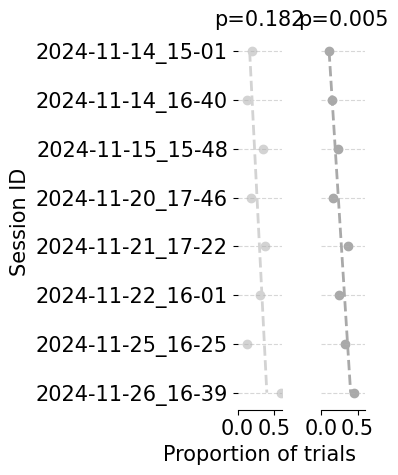

In [21]:
plt.close('all')
fig, axes = plt.subplots(figsize=(4,5), ncols=2, sharex=True)
x, y_loc1, y_loc2 = [], [], []
for s_id in trialw_beh.index.unique('session_id'):
    # print(s_id)
    a_trialw_beh = trialw_beh.loc[s_id]
    n_R_1st_location = a_trialw_beh.trial_outcome %5
    a_trialw_beh.loc[:,'n_R_1st_location'] = n_R_1st_location.values
    n_R_2nd_location = a_trialw_beh.trial_outcome //10
    a_trialw_beh.loc[:,'n_R_2nd_location'] = n_R_2nd_location.values
    n = len(a_trialw_beh)
    # print(a_trialw_beh[['trial_outcome', 'n_R_1st_location', 'n_R_2nd_location']].to_string())
    print(f"Session {s_id}: n_R1: {(n_R_1st_location>=1).sum()}/{n}, n_R2: {(n_R_2nd_location>=1).sum()}/{n}")
    
    # print(f"Session {s_id}: 1st loc R proportion: {(n_R_1st_location>1).sum()/n:.2f}, 2nd loc R proportion: {(n_R_2nd_location>1).sum()/n:.2f}")
    x.append(s_id)
    y_loc1.append((n_R_1st_location>=1).sum()/n)
    # y_loc1
    y_loc2.append((n_R_2nd_location>=1).sum()/n)

    axes[0].scatter([y_loc1[-1]], [s_id,], label='1st location R' if s_id == 0 else None, color='lightgrey')
    axes[1].scatter([y_loc2[-1]], [s_id,], label='2nd location R' if s_id == 0 else None, color='darkgrey')

# linear fit
x_num = np.arange(len(x))
slope, intercept, r_value, p_value, std_err = stats.linregress(x_num, y_loc1)
axes[0].plot(intercept + slope * x_num, x, '--', label=f'Fit: slope={slope:.3f}, p={p_value:.3f}', color='lightgrey', linewidth=2)
axes[0].set_title(f'p={p_value:.3f}')

slope, intercept, r_value, p_value, std_err = stats.linregress(x_num, y_loc2)
axes[1].plot(intercept + slope * x_num, x, '--', label=f'Fit: slope={slope:.3f}, p={p_value:.3f}', color='darkgrey', linewidth=2)
axes[1].set_title(f'p={p_value:.3f}')

axes[0].set_xlabel('Proportion of trials')
axes[0].set_ylabel('Session ID')
axes[0].set_ylim(axes[0].get_ylim()[::-1])
axes[1].set_ylim(axes[1].get_ylim()[::-1])
axes[0].set_xlim(0, .6)
axes[1].set_xlim(0, .6)
axes[1].tick_params(axis='y', which='both', left=False, labelleft=False)
# gridlines
axes[0].grid(axis='y', alpha=0.5, linestyle='--')
axes[1].grid(axis='y', alpha=0.5, linestyle='--')
# removee all spines
[ax.spines[['top', 'right', 'left']].set_visible(False) for ax in axes]



plt.tight_layout()
plt.show()

fname = os.path.join(output_dir, 'double_stop_performance.svg')
# fig.savefig(fname, format='svg', dpi=300)

KeyError: 0

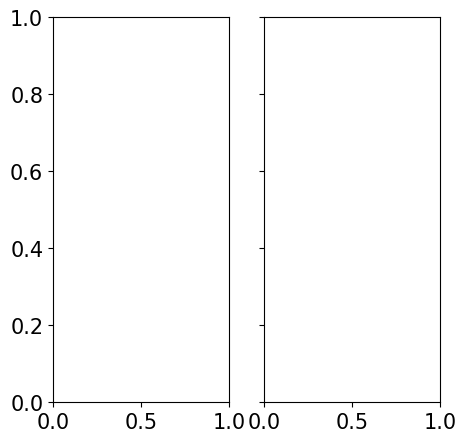

In [22]:
plt.close('all' )

choices_dict = {}
choices_n = {}

# results at session_id pie chart
fig, axes = plt.subplots(figsize=(5,5), ncols=2, sharey=True)
for i, s_id in enumerate([0, 7]):
    a_trialw_beh = trialw_beh.loc[s_id]
    print(a_trialw_beh.trial_outcome.value_counts().sort_index())
    # axes[i].hist(a_trialw_beh.trial_outcome, bins=100)
    
    n_R_1st_location = a_trialw_beh.trial_outcome %5
    n_R_2nd_location = a_trialw_beh.trial_outcome //10
    a_trialw_beh['n_R_1st_location'] = n_R_1st_location
    a_trialw_beh['n_R_2nd_location'] = n_R_2nd_location
    n = len(a_trialw_beh)

    outcomes = np.stack(((n_R_1st_location>=1).values, (n_R_2nd_location>=1).values)).T
    print(outcomes)
    print(outcomes.shape)
    n_R1_only = np.sum((outcomes[:,0]==1) & (outcomes[:,1]==0))
    n_R2_only = np.sum((outcomes[:,0]==0) & (outcomes[:,1]==1))
    n_both_R = np.sum((outcomes[:,0]==1) & (outcomes[:,1]==1))
    n_both_NR = np.sum((outcomes[:,0]==0) & (outcomes[:,1]==0))

    print(f"R1 success: {(n_R1_only+n_both_R)/n *100:.1f} %, n={n}")
    print(f"R2 success: {(n_R2_only+n_both_R)/n *100:.1f} %, n={n}")
    
    choices_dict[s_id] = {
        ('Cue1', 'R1', 'R2'): n_both_R.item(),
        ('Cue1', 'R1', 'notR2'): n_R1_only.item(),
        ('Cue1', 'notR1', 'R2'): n_R2_only.item(),
        ('Cue1', 'notR1', 'notR2'): n_both_NR.item(),
    }
    choices_n[s_id] = n
    print(f"Session {s_id}: n_R1_only: {n_R1_only}, n_R2_only: {n_R2_only}, n_both_R: {n_both_R}, n_both_NR: {n_both_NR}")

    axes[i].pie([n_R1_only, n_R2_only, n_both_R, n_both_NR], 
                labels=['R 1st loc only', 'R 2nd loc only', 'Both R', 'Both NR'],
                autopct='%1.1f%%',
                colors=['lightgreen', 'lightblue', 'green', 'red'])
    axes[i].set_title(f'Session {s_id} Reward Locations')
plt.tight_layout()
plt.show()

In [ ]:
choices_dict

{}

In [23]:
import plotly.graph_objects as go
from collections import defaultdict

def compute_node_values(data):
    """Compute total value flowing through each node."""
    node_value = defaultdict(float)
    for path, val in data.items():
        for node in path:
            node_value[node] += val
    return node_value

def organize_nodes_by_column(node_meta, node_value):
    """Group nodes by their x-coordinate."""
    columns = defaultdict(list)
    for node_id, meta in node_meta.items():
        x = meta["x"]
        columns[x].append((node_id, node_value[node_id]))
    return columns

def compute_y_positions(columns, node_meta, pad=0.02):
    """Compute vertical positions for nodes in each column."""
    final_nodes = []
    
    # Define preferred order for nodes at each x position
    preferred_order = {
        0.5: ['R1', 'notR1'],      # R1 on top
        1.0: ['R2', 'notR2'],      # R2 on top
    }
    
    for x in sorted(columns.keys()):
        group = columns[x]
        
        # If we have a preferred order for this column, use it
        if x in preferred_order:
            order_map = {node_id: i for i, node_id in enumerate(preferred_order[x])}
            ordered_group = sorted(group, key=lambda item: order_map.get(item[0], 999))
        else:
            # Otherwise sort by descending value
            ordered_group = sorted(group, key=lambda x: -x[1])
        
        # Compute normalized vertical positions
        total = sum(val for _, val in ordered_group)
        y_cursor = 0.0
        
        for node_id, val in ordered_group:
            height = val / total * (1 - pad * (len(ordered_group) - 1))
            y_center = y_cursor + height / 2
            
            final_nodes.append({
                "id": node_id,
                "label": node_meta[node_id]["label"],
                "color": node_meta[node_id]["color"],
                "x": node_meta[node_id]["x"],
                "y": y_center,
                "height": height
            })
            y_cursor += height + pad
    
    return final_nodes

def build_links(data, label_index, win_outcomes, lose_outcomes):
    """Build source, target, value arrays for Sankey links with win/lose coloring."""
    sources, targets, values, link_colors = [], [], [], []
    
    WIN_COLOR = 'rgba(79,212,79,0.4)'  # light green
    LOSE_COLOR = 'rgba(214,14,14,0.15)'  # light red
    NEUTRAL_COLOR = 'rgba(128,128,128,0.3)'  # gray
    
    for (cue, r1, r2), val in data.items():
        # Cue → R1
        sources.append(label_index[cue])
        targets.append(label_index[r1])
        values.append(val)
        
        # Color first link: green if stop (R1), red if skip (notR1)
        if r1 == 'R1':
            link_colors.append(WIN_COLOR)
        elif r1 == 'notR1':
            link_colors.append(LOSE_COLOR)
        else:
            link_colors.append(NEUTRAL_COLOR)
        
        # R1 → R2
        sources.append(label_index[r1])
        targets.append(label_index[r2])
        values.append(val)
        
        # Color second link: green if stop (R2), red if skip (notR2)
        if r2 == 'R2':
            link_colors.append(WIN_COLOR)
        elif r2 == 'notR2':
            link_colors.append(LOSE_COLOR)
        else:
            link_colors.append(NEUTRAL_COLOR)
    
    return sources, targets, values, link_colors

def render_sankey(data, node_meta, win_outcomes=None, lose_outcomes=None, 
                  title="Sankey Diagram", height=400, width=600):
    """
    Render a Sankey diagram with colored links.
    
    Parameters:
    -----------
    data : dict
        Dictionary with (cue, r1, r2) tuples as keys and flow values as values
        Example: {('Cue1', 'R1', 'R2'): 10, ('Cue1', 'R1', 'notR2'): 5, ...}
    
    node_meta : dict
        Dictionary with node metadata
        Example: {'Cue1': {'label': 'Cue1', 'color': 'orange', 'x': 0.0},
                  'R1': {'label': 'Stop', 'color': 'grey', 'x': 0.5}, ...}
    
    win_outcomes : set or list, optional
        Set of (cue, r1, r2) tuples that represent winning outcomes (colored green)
        Example: {('Cue1', 'R1', 'R2')}
    
    lose_outcomes : set or list, optional
        Set of (cue, r1, r2) tuples that represent losing outcomes (colored red)
        Example: {('Cue1', 'notR1', 'notR2')}
    
    title : str
        Plot title
    
    height, width : int
        Figure dimensions
    """
    if win_outcomes is None:
        win_outcomes = set()
    if lose_outcomes is None:
        lose_outcomes = set()
    
    # Compute node values and positions
    node_values = compute_node_values(data)
    columns = organize_nodes_by_column(node_meta, node_values)
    final_nodes = compute_y_positions(columns, node_meta)
    
    # Build label index
    label_index = {node["id"]: idx for idx, node in enumerate(final_nodes)}
    
    # Build links with colors
    sources, targets, values, link_colors = build_links(data, label_index, win_outcomes, lose_outcomes)
    
    # Create figure
    fig = go.Figure(go.Sankey(
        arrangement="fixed",
        node=dict(
            pad=15,
            thickness=15,
            line=dict(color='black', width=0.5),
            label=[n["label"] for n in final_nodes],
            color=[n["color"] for n in final_nodes],
            x=[n["x"] for n in final_nodes],
            y=[n["y"] for n in final_nodes],
        ),
        link=dict(
            line=dict(color='black', width=0.5),
            source=sources,
            target=targets,
            value=values,
            color=link_colors,
        )
    ))
    
    fig.update_layout(
        title_text=title,
        font_size=10,
        height=height,
        width=width,
    )
    
    return fig



In [24]:

  # Using session 7 data from previous analysis
node_meta = {
    'Cue1': {'label': 'Cue1', 'color': 'orange', 'x': 0.0},
    'R1': {'label': 'StopR1', 'color': 'darkgrey', 'x': 0.5},
    'notR1': {'label': 'SkipR1', 'color': 'darkgrey', 'x': 0.5},
    'R2': {'label': 'StopR2', 'color': 'lightgrey', 'x': 1.0},
    'notR2': {'label': 'SkipR2', 'color': 'lightgrey', 'x': 1.0},
}

# Define winning and losing outcomes
win_outcomes = {('Cue1', 'R1', 'R2')}  # Green: stopped at both locations
lose_outcomes = {('Cue1', 'notR1', 'notR2')}  # Red: skipped both locations

fig = render_sankey(choices_dict[0], node_meta, win_outcomes=win_outcomes, 
                   lose_outcomes=lose_outcomes, title="Session 00")
# fname = f"{output_dir}/session_00_sankey.svg"
# fig.write_image(fname)

fig.show()
fig = render_sankey(choices_dict[7], node_meta, win_outcomes=win_outcomes, 
                   lose_outcomes=lose_outcomes, title="Session 07")
fname = f"{output_dir}/session_07_sankey.svg"
fig.write_image(fname)
fig.show()

KeyError: 0

In [25]:
def extract_trial_numbers(encoding_data):
    trial_d = encoding_data[~encoding_data.trial_id.duplicated()]

    cue_1_data  = {
        ('Cue1', 'R1', 'R2'): ((trial_d.cue ==1) & (trial_d.choice_R1 == 1) & (trial_d.choice_R2 == 1)).sum().item(),
        ('Cue1', 'R1', 'notR2'): ((trial_d.cue ==1) & (trial_d.choice_R1 == 1) & (trial_d.choice_R2 == 0)).sum().item(),
        ('Cue1', 'notR1', 'R2'): ((trial_d.cue ==1) & (trial_d.choice_R1 == 0) & (trial_d.choice_R2 == 1)).sum().item(),
        ('Cue1', 'notR1', 'notR2'): ((trial_d.cue ==1) & (trial_d.choice_R1 == 0) & (trial_d.choice_R2 == 0)).sum().item(),
    }
    cue_2_data  = {
        ('Cue2', 'R1', 'R2'): ((trial_d.cue ==2) & (trial_d.choice_R1 == 1) & (trial_d.choice_R2 == 1)).sum().item(),
        ('Cue2', 'R1', 'notR2'): ((trial_d.cue ==2) & (trial_d.choice_R1 == 1) & (trial_d.choice_R2 == 0)).sum().item(),
        ('Cue2', 'notR1', 'R2'): ((trial_d.cue ==2) & (trial_d.choice_R1 == 0) & (trial_d.choice_R2 == 1)).sum().item(),
        ('Cue2', 'notR1', 'notR2'): ((trial_d.cue ==2) & (trial_d.choice_R1 == 0) & (trial_d.choice_R2 == 0)).sum().item(),
    }
    return cue_1_data, cue_2_data


trialw_beh = analytics.get_analytics('BehaviorTrialwise', session_names=session_names[:])

trialw_beh.index = trialw_beh.index.droplevel(('animal_id', 'paradigm_id', 'entry_id'))
trialw_beh

/home/samed/VirtualReality/analysisVR/analytics_processing/analytics.py:660: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  aggr = pd.concat(aggr)
2026-05-19 17:35:30,992|INFO|2097021|analytics|get_analytics
	Returning BehaviorTrialwise for 34 sessions.
Returning BehaviorTrialwise for 34 sessions.================================================================================



,trial_id,trial_start_frame,trial_start_pc_timestamp,trial_end_frame,trial_end_pc_timestamp,trial_pc_duration,trial_outcome,trial_start_ephys_timestamp,trial_end_ephys_timestamp,velocity_threshold_at_R1,...,startZone_enter_ephys_t,startZone_exit_ephys_t,visibleCue_enter_ephys_t,visibleCue_exit_ephys_t,trial_start_ephys_patched,trial_end_ephys_patched,multi_reward_requires_stop,flip_Cue1R1_Cue2R2,prob_cue1_trial,movement_gain_scaler
session_id,,,,,,,,,,,,,,,,,,,,,
2024-11-14_15-01,1,14196,1731592884285890,14864,1731592895460142,11174252,0,NaN,NaN,0.3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-11-14_15-01,2,14986,1731592897508073,15673,1731592909008677,11500604,0,NaN,NaN,0.3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-11-14_15-01,3,15795,1731592911043475,16496,1731592922729898,11686423,0,NaN,NaN,0.3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-11-14_15-01,4,16618,1731592924764315,17314,1731592936370725,11606410,0,NaN,NaN,0.4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-11-14_15-01,5,17436,1731592938409486,18056,1731592948755828,10346342,0,NaN,NaN,0.4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-01-27_13-39,148,277065,1737985853927664,278340,1737985875178413,21250749,1,4.255993e+09,4.277245e+09,0.3,...,4.255993e+09,4.266594e+09,4.266610e+09,4.267411e+09,0.0,0.0,1.0,1.0,0.5,1.0
2025-01-27_13-39,149,278462,1737985877213607,279902,1737985901219848,24006241,1,4.279278e+09,4.303286e+09,0.3,...,4.279278e+09,4.287583e+09,4.287600e+09,4.288384e+09,0.0,0.0,1.0,1.0,0.5,1.0
2025-01-27_13-39,150,280024,1737985903260421,281307,1737985926338418,23077997,0,4.305323e+09,4.328404e+09,0.3,...,4.305323e+09,4.308242e+09,4.308259e+09,4.309142e+09,0.0,0.0,1.0,1.0,0.5,1.0


In [ ]:
# trialw_beh = trialw_beh.loc[15:15]
# idx = trialw_beh.index.values
# idx = idx - (trialw_beh.trial_id<27).astype(float)
# trialw_beh.index = idx
# trialw_beh.index.name = 'session_id'
# trialw_beh

In [26]:
plt.rcParams.update({
    'font.size': 15,           # general font size
    'axes.titlesize': 15,      # subplot title
    'axes.labelsize': 15,      # x and y labels
    'xtick.labelsize': 15,     # x tick labels
    'ytick.labelsize': 15,     # y tick labels
    'legend.fontsize': 15,     # legend
})

In [27]:
plt.close('all' )
res_cue1 = []
res_cue2 = []
for s_id in trialw_beh.index.unique('session_id'):
    if (s_id <8): # or (s_id >15):
        continue
    s_trialw_beh = trialw_beh.loc[s_id]
    expert_trials = s_trialw_beh[(s_trialw_beh['choice_R1'] ==1) & 
                                 (s_trialw_beh['choice_R2'] ==0) & 
                                 (s_trialw_beh['cue'] ==1) ]
    prop_expert_trials = len(expert_trials)/len(s_trialw_beh[s_trialw_beh['cue'] ==1]) *100
    res_cue1.append((s_id, prop_expert_trials))
    
    expert_trials = s_trialw_beh[(s_trialw_beh['choice_R1'] ==0) & 
                                 (s_trialw_beh['choice_R2'] ==1) & 
                                 (s_trialw_beh['cue'] ==2) ]
    prop_expert_trials = len(expert_trials)/len(s_trialw_beh[s_trialw_beh['cue'] ==2]) *100
    res_cue2.append((s_id, prop_expert_trials))
    
    print(f"Session {s_id}: Expert trials: {len(expert_trials)/len(s_trialw_beh) *100:.1f} %, n={len(expert_trials)}")
res_cue1 = np.array(res_cue1)
res_cue2 = np.array(res_cue2)

plt.figure(figsize=(4.2,3))
plt.scatter(res_cue1[:,0], res_cue1[:,1],  color='orange')


# # linear regression, with p value
# z = np.polyfit(res_cue1[:,0], res_cue1[:,1], 1)
# p = np.poly1d(z)
# plt.plot(res_cue1[:,0], p(res_cue1[:,0]), "r--", label=f'Fit: slope={z[0]:.3f}', color='orange')

# Linear fit
m, b = np.polyfit(res_cue1[:,0], res_cue1[:,1], 1)
plt.plot(res_cue1[:,0], m*res_cue1[:,0] + b, color='orange', linestyle='--', linewidth=2)
# Correlation
corr, pval = stats.pearsonr(res_cue1[:,0], res_cue1[:,1])
plt.text(0.95, 0.5, f'r={corr:.2f}\np={pval:.3f} *', transform=plt.gca().transAxes,
         verticalalignment='bottom', horizontalalignment='right')


plt.xlabel('Session ID')
plt.ylabel('Proportion of\nexpert trials (%)')
plt.title('Expert trials')
# plt.ylim(0,50)
plt.xticks((8,9,10,11,12,13,14,15))
# y axis grid
plt.gca().yaxis.grid(True, linestyle='--', alpha=0.5)
# spines off
[plt.gca().spines[side].set_visible(False) for side in ['top', 'right', 'left']]
plt.subplots_adjust(left=0.3, bottom=.2)
plt.xlabel("Session")

# draw cue2
m, b = np.polyfit(res_cue2[:,0], res_cue2[:,1], 1)
plt.plot(res_cue2[:,0], m*res_cue2[:,0] + b, color='purple', linestyle='--', linewidth=2)
plt.scatter(res_cue2[:,0], res_cue2[:,1],  color='purple')
# Correlation
corr, pval = stats.pearsonr(res_cue2[:,0], res_cue2[:,1])
plt.text(0.95, 0.25, f'p={pval:.3f} *', transform=plt.gca().transAxes,
         verticalalignment='bottom', horizontalalignment='right')   



plt.show()

# save figure
# fname = 'export_perf_S8-15.svg'
# fname = 'export_perf_S8-15_split.svg'
# plt.savefig(os.path.join(output_dir, fname), format='svg', dpi=300)
os.path.join(output_dir, fname)

TypeError: '<' not supported between instances of 'str' and 'int'

In [ ]:
# Load the autoreload extension first
%load_ext autoreload

# Then configure it
%autoreload 2

In [ ]:
import os
import sys

import numpy as np
# to setup import paths add project root dirs to sys.path
sys.path.append(os.path.join(os.getcwd(), "..", ".."))
from baseVR.base_functionality import init_import_paths
init_import_paths()

from dashsrc.plot_components.plots import plot_unit_fr_stability
from dashsrc.plot_components.plots import plot_EnsambleEncondings
from dashsrc.plot_components.plots import plot_EnsembleChoiceEncoding
from dashsrc.plot_components.plots import plot_SessionWaveforms


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# %matplotlib qt
%matplotlib widget

from analytics_processing import analytics
import analytics_processing.analytics_constants as C
from CustomLogger import CustomLogger as Logger

from dashsrc.plot_components.plot_wrappers.data_selection import group_filter_data

from analytics_processing.modality_loading import session_modality_from_nas
from analytics_processing.sessions_from_nas_parsing import sessionlist_fullfnames_from_args
from analytics_processing.sessions_from_nas_parsing import fullfnames2snames

# import GridSpecFromSubplotSpec
from matplotlib.gridspec import GridSpecFromSubplotSpec
import scipy.stats as stats
import statsmodels.api as sm
from matplotlib.colors import LinearSegmentedColormap, Normalize


data = {}
nas_dir = C.device_paths()[0]
output_dir = os.path.join(nas_dir, 'Simon', 'poster')
Logger().init_logger(None, None, logging_level="INFO")

In [ ]:
# import plotly.graph_objects as go
# import pandas as pd
# import numpy as np
# from scipy.stats import zscore
# from scipy.cluster.hierarchy import linkage, leaves_list

# def render_plot_heatmap(spike_metadata, cluster=True):
#     """
#     Render a heatmap of average firing rates for each cluster across sessions.
    
#     Args:
#         spike_metadata (DataFrame): Contains spike metadata including cluster_id, 
#                                    session_spike_count and session_nsamples
    
#     Returns:
#         plotly.graph_objects.Figure: Heatmap of firing rates
#     """
#     # Compute average firing rate for each (cluster, session)
#     sess_spk_cnt = spike_metadata['session_spike_count']
#     sess_seconds = spike_metadata['session_nsamples'] / 20_000
    
#     # Create and format DataFrame
#     avg_frate = (sess_spk_cnt / sess_seconds).to_frame(name='avg_frate').droplevel((0, 1, 3))
#     avg_frate['cluster_id'] = spike_metadata['cluster_id'].values
#     avg_frate = avg_frate.set_index('cluster_id', append=True)
    
#     # Filter: keep only neurons that have at least one session with firing rate > 1 Hz
#     neurons_to_keep = avg_frate.groupby(level='cluster_id')['avg_frate'].max() > 1.0
#     valid_neurons = neurons_to_keep[neurons_to_keep].index
#     avg_frate = avg_frate[avg_frate.index.get_level_values('cluster_id').isin(valid_neurons)]
#     print(f"Kept {len(valid_neurons)} neurons with FR > 1 Hz in at least one session")
#     print(avg_frate)
    
#     print(avg_frate)
#     # Convert to matrix format
#     avg_frate_matrix = avg_frate.unstack(level=0)
#     avg_frate_matrix.columns = avg_frate_matrix.columns.droplevel(0)
    
#     # Define firing rate bins
#     bins = (0, 0.00001, 0.1, 1, 2, 4, 8, 16, 32, 64)
    
#     # Bin the firing rates for clustering
#     avg_frate_matrix_bin_id = np.zeros_like(avg_frate_matrix, dtype=int)
#     for i in range(len(bins) - 1):
#         from_val, to_val = bins[i], bins[i+1]
#         mask = (avg_frate_matrix > from_val) & (avg_frate_matrix <= to_val)
#         avg_frate_matrix_bin_id[mask] = i
    
#     if cluster:
#         # Hierarchical clustering
#         linkage_matrix = linkage(
#             avg_frate_matrix_bin_id, 
#             metric='cityblock', 
#             method='complete', 
#             optimal_ordering=True
#         )
#         ordered_indices = leaves_list(linkage_matrix)
        
#         # Reorder rows based on clustering results
#         avg_frate_matrix = avg_frate_matrix.iloc[ordered_indices]
        
    
#     # clip to < 1Hz, > 1Hz    
#     avg_frate_matrix.loc[:] = (avg_frate_matrix > .1).astype(float).values
    
#     # Create color scale for the heatmap
#     maxval = 32
#     eps = .000001
#     fr_cscale = [
#         [0, '#ffffff'], 
#         [(0+eps)/maxval, "#e8e8e8"], [.1/maxval, "#e8e8e8"], 
#         [(.1+eps)/maxval, "#8C6565"], [1/maxval, "#8C6565"], 
#         [(1+eps)/maxval, "#8C6565"], [2/maxval, "#8C6565"],
#         [(2+eps)/maxval, "#963F3F"], [4/maxval, "#963F3F"],
#         [(4+eps)/maxval, "#A73131"], [8/maxval, "#A73131"],
#         [(8+eps)/maxval, "#D1552C"], [16/maxval, "#D1552C"],
#         [(16+eps)/maxval, "#D1922C"], [32/maxval, "#D1922C"],
#     ]
    
#     # Create custom colorbar tick values and text
#     colorbar_tickvals = [0, 0.05, 0.5, 1.5, 3, 6, 12, 24]
#     colorbar_ticktext = ["Not detected", "<0.1 Hz", "<1 Hz", "<2 Hz", "<4 Hz", "<8 Hz", "<16 Hz", "<32 Hz"]
    
#     # Create heatmap figure
#     fig = go.Figure(
#         data=go.Heatmap(
#             z=avg_frate_matrix.values,
#             x=np.arange(avg_frate_matrix.columns.size),
#             y=np.arange(avg_frate_matrix.index.size),
#             colorscale=fr_cscale,
#             colorbar=dict(
#                 title='Avg Firing Rate',
#                 tickvals=colorbar_tickvals,
#                 ticktext=colorbar_ticktext,
#                 tickmode='array',
#                 len=0.75,
#                 thickness=20,
#                 tickfont=dict(size=10)
#             ),
#             zmin=0,
#             zmax=maxval,
#         )
#     )
    
#     # Add manual vertical grid lines for each session
#     for i in range(avg_frate_matrix.columns.size + 1):
#         fig.add_shape(
#             type="line",
#             x0=i - 0.5, x1=i - 0.5,
#             y0=-0.5, y1=avg_frate_matrix.index.size - 0.5,
#             line=dict(color="rgba(128, 128, 128, 0.3)", width=1),
#             layer="above"
#         )
    
#     # Add manual horizontal grid lines for each neuron
#     for i in range(avg_frate_matrix.index.size + 1):
#         fig.add_shape(
#             type="line",
#             x0=-0.5, x1=avg_frate_matrix.columns.size - 0.5,
#             y0=i - 0.5, y1=i - 0.5,
#             line=dict(color="rgba(128, 128, 128, 0.3)", width=1),
#             layer="above"
#         )
    
#     # Prepare x-axis tick labels (show every second session ID)
#     session_ids = avg_frate_matrix.columns.tolist()
#     tickvals = np.arange(avg_frate_matrix.columns.size)
#     ticktext = [session_ids[i] if i % 2 == 0 else "" for i in range(len(session_ids))]
    
#     # Update layout with reduced width
#     fig.update_layout(
#         width=400,  # Reduced to half (was 800)
#         height=len(avg_frate_matrix.index)* 5 + 200,
#         xaxis_title="Session ID",
#         yaxis_title="Single Unit ID",
#         title="Average Firing Rate per Neuron/Session",
#         template="plotly_white",
#         yaxis=dict(
#             tickmode='array',
#             tickvals=np.arange(avg_frate_matrix.index.size),
#             ticktext=[""] * avg_frate_matrix.index.size,  # Empty labels
#             tickfont=dict(size=8, color='black'),
#             showgrid=False,
#         ),
#         xaxis=dict(
#             tickmode='array',
#             tickvals=tickvals,
#             ticktext=ticktext,
#             tickfont=dict(size=15, color='black'),
#             showgrid=False,
#             tickangle=0,  # No rotation
#         )
#     )
#     return fig

In [ ]:

# from dashsrc.plot_components.plots import plot_unit_fr_stability


animal_ids = [6]
# animal_ids = [10]
session_ids = None
paradigm_ids = [1100]
excl_session_names = ['2024-11-29_17-21_rYL006_P1100_LinearTrackStop_28min', '2025-01-21_18-49_rYL006_P1100_LinearTrackStop_30min', '2024-12-11_17-42_rYL006_P1100_LinearTrackStop_30min']
cols = ["session_spike_count", "session_nsamples", "cluster_id", "unit_snr", "unit_Vpp"]
width = 700
height = 700
group_by = None

data['SpikeClusterMetadata'] = analytics.get_analytics('SpikeClusterMetadata', mode='set',
                                                      #  columns = cols,
                                                       paradigm_ids=paradigm_ids,
                                                       animal_ids=animal_ids,
                                                       excl_session_names=excl_session_names,
                                                       session_ids=session_ids)

# HPC
# data['SpikeClusterMetadata'] = data['SpikeClusterMetadata'][data['SpikeClusterMetadata'].cluster_id<=20]
# mPFC
# data['SpikeClusterMetadata'] = data['SpikeClusterMetadata'][data['SpikeClusterMetadata'].cluster_id>20]
fig = plot_unit_fr_stability.render_plot_heatmap(data['SpikeClusterMetadata'])
# fig = render_plot_heatmap(data['SpikeClusterMetadata'])

fig.show()
# save
fname = f'unit_fr_stability_mPFC.svg'
# fname = f'unit_fr_stability_hp.svg'
# fig.write_image(os.path.join(output_dir, fname), format='svg', )


2026-01-26 14:54:37,655|INFO|314889|analytics|get_analytics
	Analytic `SpikeClusterMetadata` not does not exist for (1100, 6, '2024-11-14_15-01'), compute first, or check for typo
2026-01-26 14:54:37,655|INFO|314889|analytics|get_analytics
	Analytic `SpikeClusterMetadata` not does not exist for (1100, 6, '2024-11-14_15-01'), compute first, or check for typo
2026-01-26 14:54:38,095|INFO|314889|analytics|get_analytics
	Analytic `SpikeClusterMetadata` not does not exist for (1100, 6, '2024-11-22_16-01'), compute first, or check for typo
2026-01-26 14:54:38,095|INFO|314889|analytics|get_analytics
	Analytic `SpikeClusterMetadata` not does not exist for (1100, 6, '2024-11-22_16-01'), compute first, or check for typo
2026-01-26 14:54:38,302|INFO|314889|analytics|get_analytics
	Analytic `SpikeClusterMetadata` not does not exist for (1100, 6, '2024-11-27_16-11'), compute first, or check for typo
2026-01-26 14:54:38,302|INFO|314889|analytics|get_analytics
	Analytic `SpikeClusterMetadata` not doe

KeyError: 'Version'

In [ ]:
plt.rcParams.update({
    'font.size': 15,           # general font size
    'axes.titlesize': 15,      # subplot title
    'axes.labelsize': 15,      # x and y labels
    'xtick.labelsize': 15,     # x tick labels
    'ytick.labelsize': 15,     # y tick labels
    'legend.fontsize': 15,     # legend
})

77


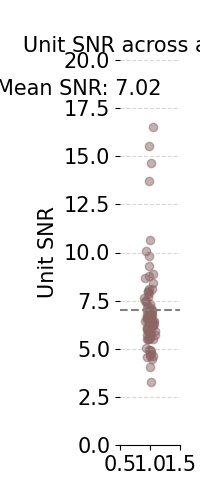

In [ ]:


plt.close('all' )

plt.figure(figsize=(2,5))
# left space
plt.subplots_adjust(left=0.6)
vals = data['SpikeClusterMetadata'].unit_snr.values
vals = np.unique(vals)
print(len(vals))

x_jitter = np.random.normal(0, 0.04, size=len(vals)) + 1
mean_snr = np.mean(vals)
plt.axhline(mean_snr, color='gray', linestyle='--', label=f'Mean SNR: {mean_snr:.2f}')
plt.legend(frameon=False, loc='upper right')
plt.ylabel('Unit SNR')
plt.title('Unit SNR across all units')
# no spines
[plt.gca().spines[side].set_visible(False) for side in ['top', 'right', 'left']]
# drop duplicates (every sessionhas same snr)
plt.scatter(x_jitter, vals, alpha=.5, color='#8c6565')
plt.xlim(0.5, 1.5)
# add y axis grid
plt.gca().yaxis.grid(True, linestyle='--', alpha=0.5)
plt.ylim(0,20)

plt.show()

plt.savefig(os.path.join(output_dir, 'unit_snr_allunits.svg'), format='svg', dpi=300)

In [ ]:

data['Spikes'] = analytics.get_analytics('Spikes', mode='set',
                                        #  columns = ['amplitude_uV', 'cluster_id'],
                                        paradigm_ids=paradigm_ids,
                                        animal_ids=animal_ids,
                                        excl_session_names=excl_session_names,
                                        session_ids=session_ids)

2025-11-14 14:12:31,449|INFO|3203154|analytics|get_analytics
	Analytic `Spikes` not does not exist for (1100, 6, 0), compute first, or check for typo
2025-11-14 14:12:31,449|INFO|3203154|analytics|get_analytics
	Analytic `Spikes` not does not exist for (1100, 6, 0), compute first, or check for typo
INFO	Task(Task-2) __main__:analytics.py:get_analytics()- Analytic `Spikes` not does not exist for (1100, 6, 0), compute first, or check for typo
2025-11-14 14:12:33,769|INFO|3203154|analytics|get_analytics
	Analytic `Spikes` not does not exist for (1100, 6, 5), compute first, or check for typo
2025-11-14 14:12:33,769|INFO|3203154|analytics|get_analytics
	Analytic `Spikes` not does not exist for (1100, 6, 5), compute first, or check for typo
INFO	Task(Task-2) __main__:analytics.py:get_analytics()- Analytic `Spikes` not does not exist for (1100, 6, 5), compute first, or check for typo
2025-11-14 14:12:34,867|INFO|3203154|analytics|get_analytics
	Analytic `Spikes` not does not exist for (1100, 

In [ ]:


# sess_Vpp = data['Spikes'].reset_index()[['session_id','cluster_id','amplitude_uV']].groupby(['session_id','cluster_id']).mean()

# highlight_cluster = 46
# fig = plot_unit_fr_stability.render_plot_amplitude(data['SpikeClusterMetadata'], sess_Vpp, highlight_cluster)
# fullfname = f'{output_dir}/unit_fr_stability_ampl46.svg'
# fig.write_image(fullfname, width=800, height=400, scale=1)
# execute = f"code {fullfname}"
# os.system(execute)
# fig.show()

# highlight_cluster = 15
# fig = plot_unit_fr_stability.render_plot_amplitude(data['SpikeClusterMetadata'], sess_Vpp, highlight_cluster)
# fullfname = f'{output_dir}/unit_fr_stability_ampl15.svg'
# fig.write_image(fullfname, width=800, height=400, scale=1)
# execute = f"code {fullfname}"
# os.system(execute)
# fig.show()


# only spines 17,18,19
d = data['SpikeClusterMetadata'][data['SpikeClusterMetadata'].cluster_id.isin([52,53,54])]

data["SessionMetadata"] = analytics.get_analytics('SessionMetadata', mode='set',
                                         paradigm_ids=paradigm_ids,
                                         animal_ids=animal_ids,
                                         excl_session_names=excl_session_names,
                                         session_ids=session_ids)
fig = plot_SessionWaveforms.render_plot(d, data['SessionMetadata'],
                                        width, height,)
fig.show()



fname = f'all_units_waveforms.svg'
fig.write_image(os.path.join(output_dir, fname), format='svg', )

2025-11-14 14:22:19,792|INFO|3203154|analytics|get_analytics
	Returning SessionMetadata for 31 sessions.
Returning SessionMetadata for 31 sessions.================================================================================

INFO	Task(Task-2) __main__:analytics.py:get_analytics()- Returning SessionMetadata for 31 sessions.


Processing cluster 1 (1/77)
Processing cluster 2 (2/77)
Processing cluster 3 (3/77)
Processing cluster 4 (4/77)
Processing cluster 5 (5/77)
Processing cluster 6 (6/77)
Processing cluster 7 (7/77)
Processing cluster 8 (8/77)
Processing cluster 9 (9/77)
Processing cluster 10 (10/77)
Processing cluster 11 (11/77)
Processing cluster 12 (12/77)
Processing cluster 13 (13/77)
Processing cluster 14 (14/77)
Processing cluster 15 (15/77)
Processing cluster 16 (16/77)
Processing cluster 17 (17/77)
Processing cluster 18 (18/77)
Processing cluster 19 (19/77)
Processing cluster 20 (20/77)
Processing cluster 21 (21/77)
Processing cluster 22 (22/77)
Processing cluster 23 (23/77)
Processing cluster 24 (24/77)
Processing cluster 25 (25/77)
Processing cluster 26 (26/77)
Processing cluster 27 (27/77)
Processing cluster 28 (28/77)
Processing cluster 29 (29/77)
Processing cluster 30 (30/77)
Processing cluster 31 (31/77)
Processing cluster 32 (32/77)
Processing cluster 33 (33/77)
Processing cluster 34 (34/77